# SNR / Exposure Time Map

Build a HEALPix sky grid and, for a single observing time, evaluate the UVEX spacecraft location
and the FUV signal-to-noise ratio (SNR) reached by a single `DWELL_DURATION` dwell on a
`SOURCE_MAG` source at every pixel. The result is rendered two ways:

1. **A static all-sky map** at the reference time `TIME`.
2. **An animation** stepping from `ANIMATION_START_TIME` to `ANIMATION_END_TIME`, recomputing the
   SNR map, the Sun/Moon/Earth positions, and the combined field-of-regard exclusion
   (`mission.constraints`: `EarthLimbConstraint` \| `SunSeparationConstraint` \|
   `MoonSeparationConstraint`) at each frame, since all of these depend on the spacecraft's
   position along its orbit.

This methodology mirrors the exposure-weight grid computed in `main.ipynb` (same
`mission.detector` model, source brightness, and bandpass, and the field-of-regard animation in `m4opt`'s own
`m4opt animate` CLI command (`m4opt._cli.animate`), just evaluated on a plain HEALPix grid rather
than a specific skymap or survey schedule.

In [74]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [75]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import numpy as np
import synphot
from astropy import units as u
from astropy.coordinates import ICRS, get_body
from astropy.time import Time
from astropy_healpix import HEALPix
from ligo.skymap import plot  # noqa: F401
from ligo.skymap.plot.marker import earth, moon, sun
from m4opt.missions import uvex as mission
from m4opt.synphot import observing
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Patch
from tqdm.auto import tqdm

In [76]:
# ========================================= #
# ``%%skipif`` cell magic                   #
# ========================================= #
# Lets a cell be gated behind a boolean setting (e.g. ``SHOW_BLOCK_PARTITION_PROGRESS``)
# without commenting it out. The expression on the magic line is evaluated
# against the notebook namespace; if it is True, the rest of the cell is not
# executed. Usage: ``%%skipif <expr>`` as the first line of a cell.
from IPython import get_ipython
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skipif(line, cell):
    # Evaluate the expression given to the magic command
    if eval(line, get_ipython().user_ns):
        print(f"Cell skipped: condition '{line}' is True.")
        return
    # If False, execute the cell code normally
    get_ipython().run_cell(cell)

### Configuration Settings

A number of configuration settings are available in this notebook. Please configure the options below to your liking. The default settings are recommended for most users.

In [77]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- CORE SETTINGS --- #
OUTPUT_PATH = Path("../preliminary_survey")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- HEALPIX SETTINGS --- #
# Resolution of the sky grid used for both the static map and the animation.
HEALPIX_NSIDE = 128

# --- OBSERVING TIME SETTINGS --- #
# TIME: Reference time for the static SNR map (Figure 1) below -- fixes the spacecraft location,
#       and therefore the Sun/Moon/Earth geometry, at a single instant.
TIME = Time("2030-01-01T00:00:00")

# --- SNR SETTINGS --- #
# DWELL_DURATION / SOURCE_MAG / BANDPASS: the dwell time, reference source brightness (constant
#     flux density), and bandpass used to compute the SNR reached at each pixel. DWELL_DURATION
#     matches main.ipynb's per-field dwell time; SOURCE_MAG/BANDPASS match the source brightness
#     and band main.ipynb uses for its per-slot exposure-weight grid, for consistency with the
#     rest of the pipeline.
DWELL_DURATION = 900 * u.second
SOURCE_MAG = 24.5 * u.ABmag
BANDPASS = "FUV"

# --- ANIMATION SETTINGS --- #
# Spans one UVEX orbital period (~13.7 day, TESS-like -- see mission.observer_location) by
# default, since the Earth-limb exclusion -- the fastest-changing of the three field-of-regard
# constraints -- sweeps once around the sky over that time. The SNR map, Sun/Moon/Earth positions,
# and excluded region are all recomputed at every frame, since all of them depend on where the
# spacecraft is along its orbit at that frame's time.
SAVE_FIELD_OF_REGARD_ANIMATION = True
ANIMATION_START_TIME = TIME
ANIMATION_END_TIME = TIME + 14 * u.day
ANIMATION_N_FRAMES = 100
ANIMATION_INTERVAL = 100  # milliseconds between frames
ANIMATION_DPI = 150
ANIMATION_PATH = OUTPUT_PATH / "field_of_regard_animation.mp4"

# --- VISUALIZATION SETTINGS --- #
# FIGURE_CMAP / FIGURE_NORM / FIGURE_MIN / FIGURE_MAX: colormap and color scale for the SNR maps
#     (Figure 1 and the animation). FIGURE_NORM is "log" or "linear"; FIGURE_MIN/FIGURE_MAX are
#     the color scale bounds in SNR units, or None to default to that map's own data range (see
#     make_color_norm below). FIGURE_CMAP is reversed ("_r") and FIGURE_MIN is pinned to
#     SNR_TARGET, so every pixel that fails to reach the target SNR clips to the same extreme
#     (brightest, for a "_r" colormap) color rather than fading out gradually.
# FIGURE_ROR_COLOR: fill color for the shaded excluded region (outside the field of regard).
SAVE_SNR_MAP_PLOT = True
FIGURE_CMAP = "viridis"
FIGURE_ROR_COLOR = "red"
FIGURE_NORM = "linear"
FIGURE_MIN, FIGURE_MAX = 1e0, None

## Sky Grid

Build the HEALPix grid used as the set of target pixels for both the static map and the
animation below.

In [78]:
# ========================================= #
# Construct the HEALPix Sky Grid            #
# ========================================= #
HPX = HEALPix(nside=HEALPIX_NSIDE, frame=ICRS())
TARGET_COORDS = HPX.healpix_to_skycoord(np.arange(HPX.npix))

## Helpers

Shared logic used by both Figure 1 (a single time) and the animation (many times):

- `compute_frame`: spacecraft location, exposure-time map, field-of-regard mask, and Sun/Moon/Earth
  positions at a given time.
- `make_color_norm`: the `FIGURE_CMAP` color scale (`FIGURE_NORM`, `FIGURE_MIN`, `FIGURE_MAX`) for
  an exptime map, defaulting to that map's own data range wherever a bound is left as `None`.
- `add_field_of_regard_patch` / `add_body_markers`: draw the excluded-region shading (in
  `FIGURE_ROR_COLOR`) and the Earth/Sun/Moon markers on an axis.

In [79]:
# ========================================= #
# Shared Helper Functions                   #
# ========================================= #
def compute_frame(t):
    """Observer location, SNR map, field-of-regard mask, and Sun/Moon/Earth positions at time t."""
    observer_location = mission.observer_location(t)
    with observing(observer_location, TARGET_COORDS, t):
        snr = mission.detector.get_snr(
            DWELL_DURATION,
            synphot.SourceSpectrum(synphot.ConstFlux1D, amplitude=SOURCE_MAG),
            BANDPASS,
        )
    # True where observable (all of EarthLimb/SunSeparation/MoonSeparation are satisfied).
    field_of_regard = mission.constraints(observer_location, TARGET_COORDS, t)
    earth_coord = get_body("earth", t, observer_location)
    sun_coord = get_body("sun", t, observer_location)
    moon_coord = get_body("moon", t, observer_location)
    return snr, field_of_regard, earth_coord, sun_coord, moon_coord


def make_color_norm(data, norm=FIGURE_NORM, vmin=FIGURE_MIN, vmax=FIGURE_MAX):
    """Normalize/LogNorm for an SNR map, from FIGURE_NORM/FIGURE_MIN/FIGURE_MAX.

    A `None` bound defaults to that map's own data range, restricted to finite pixels (and, for
    FIGURE_NORM="log", strictly positive pixels, since LogNorm cannot accept a zero, negative, or
    non-finite bound).
    """
    data = np.asarray(data)
    finite = np.isfinite(data)
    if norm == "log":
        finite &= data > 0
    if vmin is None:
        vmin = np.nanmin(data[finite])
    if vmax is None:
        vmax = np.nanmax(data[finite])
    return LogNorm(vmin=vmin, vmax=vmax) if norm == "log" else Normalize(vmin=vmin, vmax=vmax)


def add_field_of_regard_patch(ax, field_of_regard, alpha=0.5):
    """Shade the pixels excluded by Earth limb / Sun separation / Moon separation."""
    return ax.contourf_hpx(
        field_of_regard, nested=False, levels=[-1, 0.5], colors=[FIGURE_ROR_COLOR], alpha=alpha
    )


def add_body_markers(ax, transform, earth_coord, sun_coord, moon_coord):
    """Plot Earth/Sun/Moon position markers, as seen from the spacecraft."""
    (earth_artist,) = ax.plot(
        earth_coord.ra.deg,
        earth_coord.dec.deg,
        marker=earth,
        mec="black",
        transform=transform,
        zorder=10,
    )
    (sun_artist,) = ax.plot(
        sun_coord.ra.deg,
        sun_coord.dec.deg,
        marker=sun,
        mec="black",
        transform=transform,
        zorder=10,
    )
    (moon_artist,) = ax.plot(
        moon_coord.ra.deg,
        moon_coord.dec.deg,
        marker=moon(-115),
        mfc="black",
        mec="none",
        transform=transform,
        zorder=10,
    )
    return earth_artist, sun_artist, moon_artist

## Figure 1: SNR Map

Evaluate the spacecraft location at the single reference time `TIME`, then compute the SNR reached
by a single `DWELL_DURATION` dwell on a `SOURCE_MAG` source at every pixel under the sky
background (`mission.detector.background`) predicted for that location/time.

In [80]:
# ========================================= #
# Evaluate Spacecraft Location and SNR      #
# ========================================= #
SNR_MAP, FIELD_OF_REGARD, EARTH_COORD, SUN_COORD, MOON_COORD = compute_frame(TIME)

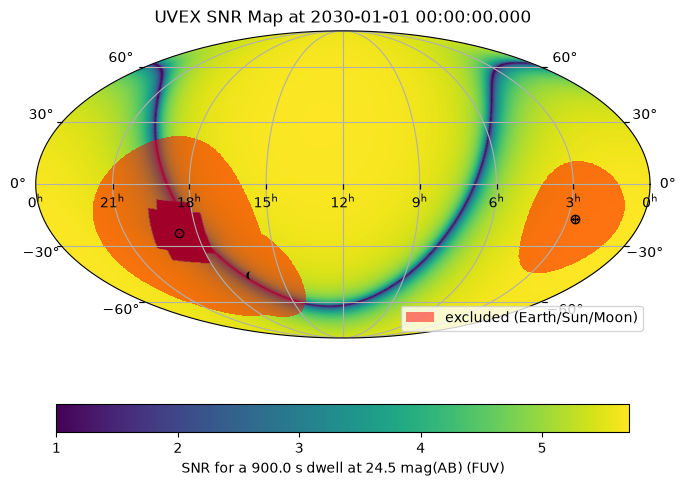

In [81]:
# ========================================= #
# Plot the SNR Map                          #
# ========================================= #
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(projection="astro hours mollweide")
ax.grid()
transform = ax.get_transform("world")

im = ax.imshow_hpx(SNR_MAP, nested=False, cmap=FIGURE_CMAP, norm=make_color_norm(SNR_MAP))
fig.colorbar(
    im,
    ax=ax,
    label=f"SNR for a {DWELL_DURATION} dwell at {SOURCE_MAG} ({BANDPASS})",
    orientation="horizontal",
    shrink=0.7,
)

add_field_of_regard_patch(ax, FIELD_OF_REGARD)
add_body_markers(ax, transform, EARTH_COORD, SUN_COORD, MOON_COORD)
ax.legend(
    handles=[Patch(facecolor=FIGURE_ROR_COLOR, alpha=0.5, label="excluded (Earth/Sun/Moon)")],
    loc="lower right",
)

ax.set_title(f"UVEX SNR Map at {TIME.iso}")
fig.tight_layout()

if SAVE_SNR_MAP_PLOT:
    fig.savefig(OUTPUT_PATH / "snr_map.pdf", dpi=300, metadata={"CreationDate": None})

## Animation: Field of Regard Over Time

Animate the SNR map from `ANIMATION_START_TIME` to `ANIMATION_END_TIME`. At each frame:

- The SNR map is recomputed at that frame's spacecraft location and time.
- The Sun, Moon, and Earth positions (as seen from the spacecraft) are recomputed and overlaid as
  markers.
- The combined field-of-regard exclusion -- `mission.constraints`, i.e. wherever
  `EarthLimbConstraint`, `SunSeparationConstraint`, or `MoonSeparationConstraint` is violated -- is
  recomputed and shaded, the same "field of regard" mask drawn by `m4opt`'s own `m4opt animate`
  CLI command.

Controlled by `SAVE_FIELD_OF_REGARD_ANIMATION` -- on by default, but this is the expensive part of
the notebook since the SNR map and field-of-regard mask are both recomputed at every one of
`ANIMATION_N_FRAMES` frames. A `tqdm` progress bar tracks frame rendering.

Rendering animation: 101it [00:50,  2.01it/s]                         


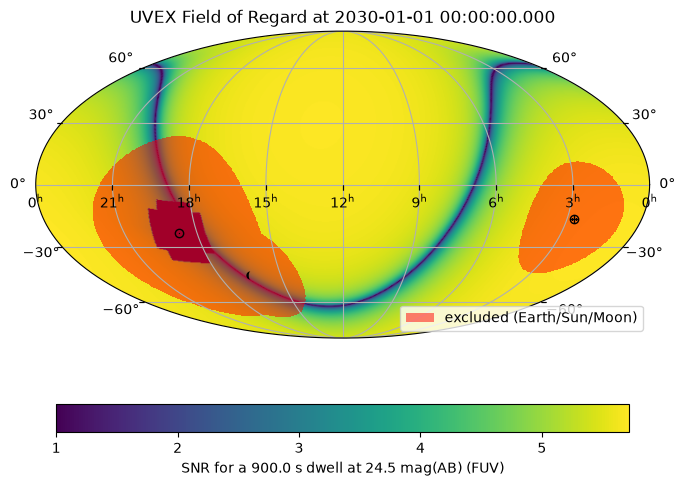

In [82]:
%%skipif not SAVE_FIELD_OF_REGARD_ANIMATION
# ========================================= #
# Animate the Field of Regard               #
# ========================================= #
ANIMATION_TIMES = ANIMATION_START_TIME + np.linspace(0, 1, ANIMATION_N_FRAMES) * (
    ANIMATION_END_TIME - ANIMATION_START_TIME
)

_snr0, _field_of_regard0, _earth0, _sun0, _moon0 = compute_frame(ANIMATION_TIMES[0])
# Fixed color scale across all frames (from the first frame, unless FIGURE_MIN/FIGURE_MAX pin it
# explicitly), so frame-to-frame color changes reflect real background variation rather than a
# rescaled colorbar.
NORM = make_color_norm(_snr0)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(projection="astro hours mollweide")
ax.grid()
transform = ax.get_transform("world")

im = ax.imshow_hpx(_snr0, nested=False, cmap=FIGURE_CMAP, norm=NORM)
fig.colorbar(
    im,
    ax=ax,
    label=f"SNR for a {DWELL_DURATION} dwell at {SOURCE_MAG} ({BANDPASS})",
    orientation="horizontal",
    shrink=0.7,
)

excluded_artist = add_field_of_regard_patch(ax, _field_of_regard0)
earth_artist, sun_artist, moon_artist = add_body_markers(ax, transform, _earth0, _sun0, _moon0)
ax.legend(
    handles=[Patch(facecolor=FIGURE_ROR_COLOR, alpha=0.5, label="excluded (Earth/Sun/Moon)")],
    loc="lower right",
)
title = ax.set_title(f"UVEX Field of Regard at {ANIMATION_TIMES[0].iso}")
fig.tight_layout()

with tqdm(total=ANIMATION_N_FRAMES, desc="Rendering animation") as progress:

    def animate(i):
        global im, excluded_artist
        t = ANIMATION_TIMES[i]
        snr, field_of_regard, earth_coord, sun_coord, moon_coord = compute_frame(t)

        # imshow_hpx/contourf_hpx re-reproject onto the axes internally, so there is no cheap
        # set_array update path -- remove and redraw each frame instead (blit=False below).
        im.remove()
        im = ax.imshow_hpx(snr, nested=False, cmap=FIGURE_CMAP, norm=NORM)

        excluded_artist.remove()
        excluded_artist = add_field_of_regard_patch(ax, field_of_regard)

        earth_artist.set_data([earth_coord.ra.deg], [earth_coord.dec.deg])
        sun_artist.set_data([sun_coord.ra.deg], [sun_coord.dec.deg])
        moon_artist.set_data([moon_coord.ra.deg], [moon_coord.dec.deg])
        title.set_text(f"UVEX Field of Regard at {t.iso}")

        progress.update()
        return [im, excluded_artist, earth_artist, sun_artist, moon_artist, title]

    ani = FuncAnimation(
        fig, animate, frames=ANIMATION_N_FRAMES, interval=ANIMATION_INTERVAL, blit=False
    )
    ani.save(ANIMATION_PATH, dpi=ANIMATION_DPI)